In [2]:
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np

In [3]:
p1 = "/Users/tizianocausin/Downloads/baby1_220226_AlexNet_RSA.mat"
p_interp = "/Users/tizianocausin/Downloads/baby1_220226_AlexNet_RSAinterpolated.mat"


In [78]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    title_fontsize=40
    labels_fontsize = 30
    ticks_fontsize = 15
    legend_fontsize=40
    fig_dir = "/Users/tizianocausin/Library/CloudStorage/GoogleDrive-tiziano.causin@unitn.it/My Drive/presentations/posters/DS_day26/figures"
    dummy_areas = ["V1", "V4", "IT"]
cfg = Cfg()

In [5]:
rsa = loadmat(p1)['rsa']
print(rsa.shape)

(22, 50)


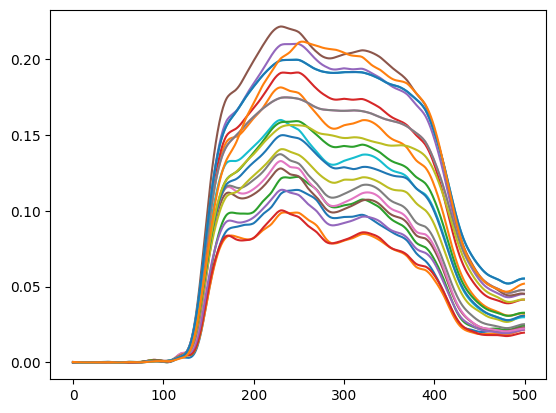

In [6]:
rsa_interp = loadmat(p_interp)['rsasm']
plt.plot(rsa_interp.T);

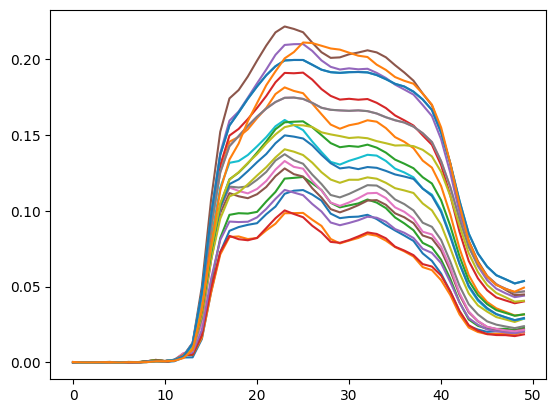

In [7]:
plt.plot(rsa.T);

In [8]:
def softmax(x, T=1.0):
    x = np.array(x) / T
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

In [9]:
softmax(np.array([5, 5, 2]))

array([0.48785555, 0.48785555, 0.0242889 ])

In [10]:
layers_depths = []
abs_max = []
n_layers, n_timepts = rsa_interp.shape
layers_idx = np.arange(1, n_layers+1)
T = .05
for t in range(n_timepts):
    mods = rsa_interp[:, t]
    layer_depth_t = layers_idx@softmax(mods, T=T)
    abs_max.append(np.argmax(mods))
    layers_depths.append(layer_depth_t)

    


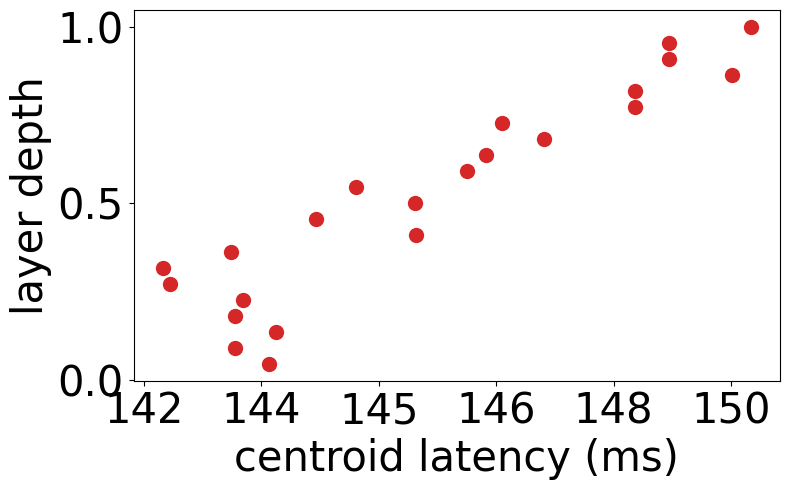

In [86]:
centroids = []
for l in range(n_layers):
    centroids.append(np.average(np.arange(n_timepts), weights=rsa_interp[l,:]))
t_min = min(centroids)
t_max = max(centroids)

cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(layers_idx)))  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))

n_ticks = 6
ticks = np.round(np.linspace(t_min, t_max, n_ticks))
ax.scatter(centroids, layers_idx/len(layers_idx),  s=100, color="tab:red") #,color=colors)
ax.tick_params(labelsize=cfg.labels_fontsize)
ax.set_xticks(ticks, np.round(ticks/2).astype(int))

ax.set_ylabel("layer depth", fontsize=cfg.labels_fontsize)
ax.set_xlabel("centroid latency (ms)", fontsize=cfg.labels_fontsize);
fig.tight_layout()
plt.savefig(f"{cfg.fig_dir}/feedforward_centroid_lat_B1.svg")

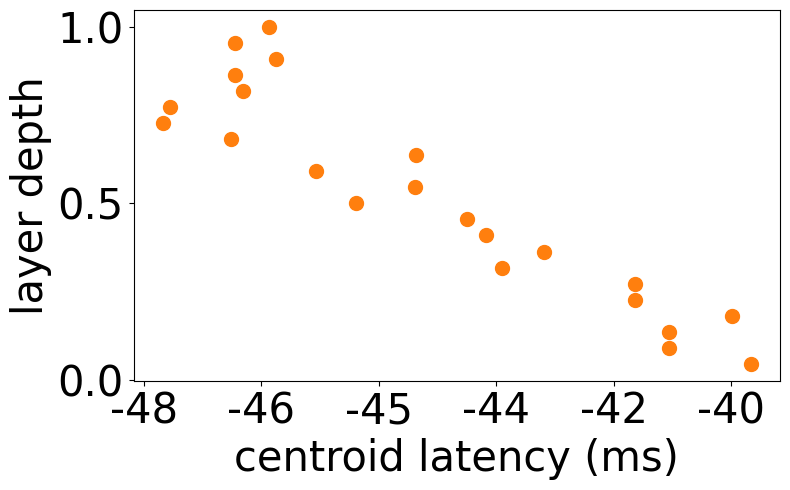

In [88]:
centroids = []
for l in range(n_layers):
    centroids.append(np.average(np.arange(n_timepts), weights=rsa_interp[l,:]))
t_min = min(centroids)
t_max = max(centroids)

cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(layers_idx)))  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))

n_ticks = 6
ticks = np.round(np.linspace(t_min, t_max, n_ticks))
ax.scatter(centroids[::-1], layers_idx/len(layers_idx),  s=100,color="tab:orange" ) #colors)
ax.tick_params(labelsize=cfg.labels_fontsize)
tick_lab = np.round(ticks/2).astype(int) - 190
ax.set_xticks(ticks, tick_lab)

ax.set_ylabel("layer depth", fontsize=cfg.labels_fontsize)
ax.set_xlabel("centroid latency (ms)", fontsize=cfg.labels_fontsize);
fig.tight_layout()
plt.savefig(f"{cfg.fig_dir}/feedback_centroid_lat_B1.svg")

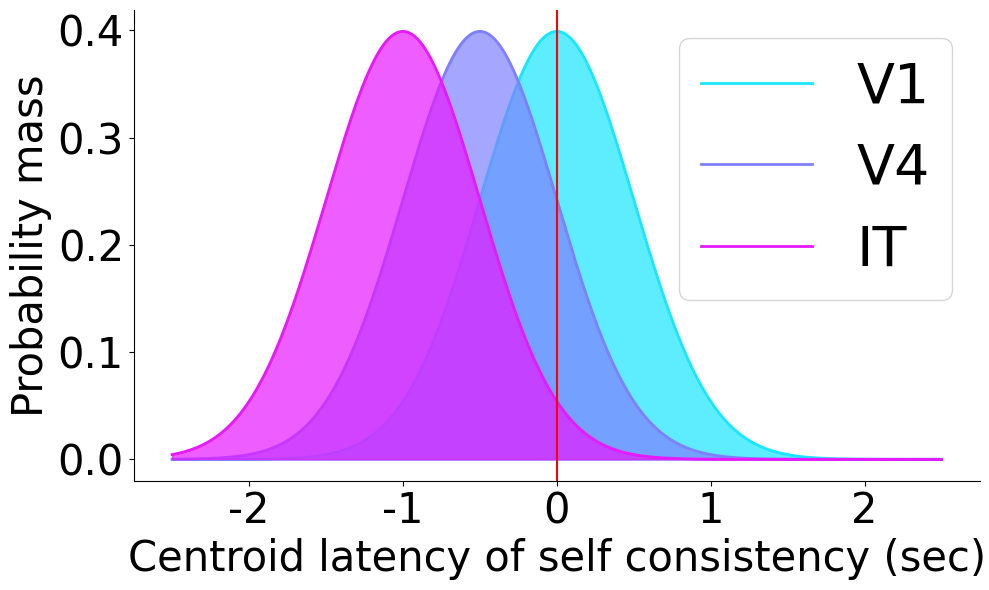

In [89]:
x = np.linspace(-5, 5, 1000)
means = [0, -1, -2]
std = 1
cmap=plt.cm.cool_r
colors = cmap(np.linspace(0.1, 0.9, len(means)))[::-1]  # pick evenly spaced colors
plt.figure(figsize=(10, 6))
for mean, color, a in zip(means, colors, cfg.dummy_areas):
    y = (1 / (std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x-mean)/std)**2)
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    plt.style.use('default')  # prevent style interference
    plt.plot(x, y, linewidth=2, color=color, zorder=1, label=a)
    ax = plt.gca()
    ax.tick_params(labelsize=cfg.labels_fontsize)
    ax.set_xticks([-4, -2, 0, 2, 4])
    ax.set_xticklabels([-2, -1, 0, 1, 2])
    plt.fill_between(x, y, 0, color=color, alpha=.7, zorder=1)
    plt.box('off')
plt.xlabel("Centroid latency of self consistency (sec)", fontsize=cfg.labels_fontsize)
plt.ylabel("Probability mass", fontsize=cfg.labels_fontsize)
plt.legend(fontsize=cfg.legend_fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.axvline(0, color='r')
plt.tight_layout()
plt.savefig(f"{cfg.fig_dir}/prob_distributions.pdf")
plt.show()

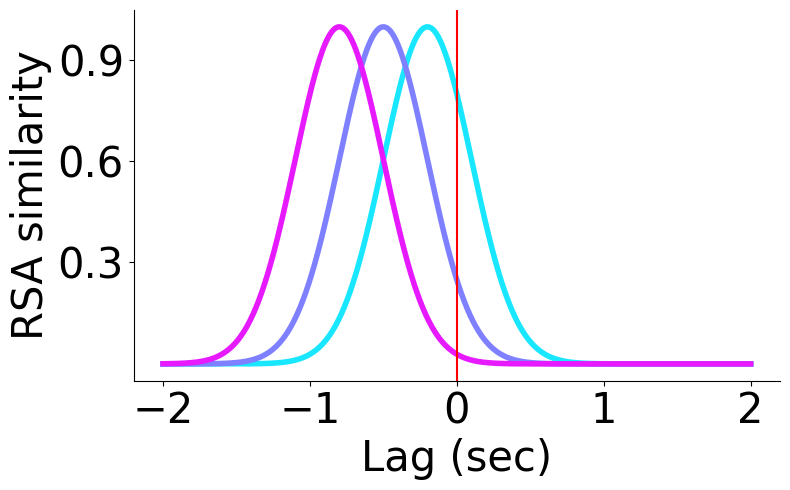

In [90]:
x = np.linspace(-2, 2, 1000)
fig, ax = plt.subplots(figsize=(8, 5))
means = [-0.2, -.5, -.8]
std = .3
for mean, color, a in zip(means, colors, cfg.dummy_areas):
    y = (1 / (std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x-mean)/std)**2)
    ax.plot(x, y, linewidth=4, color=color, label=a)
# ax.legend(fontsize=cfg.legend_fontsize)
ax.set_yticks([.4, .8, 1.2])
ax.set_yticklabels([.3, .6, .9])
ax.set_xticks([-2, -1, 0, 1, 2])
ax.tick_params(labelsize=cfg.labels_fontsize)
ax.set_xlabel("Lag (sec)", fontsize=cfg.labels_fontsize)
ax.set_ylabel("RSA similarity", fontsize=cfg.labels_fontsize)
# ax.set_title("static modeling dynamic condition", fontsize=cfg.title_fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.axvline(0, color='r')
plt.tight_layout()
plt.savefig(f"{cfg.fig_dir}/static_dynamic_lagplots.pdf")
plt.show()